In [14]:
import pandas as pd 
import numpy as np
import os
import warnings
from arch import arch_model
from statsmodels.tsa.arima.model import ARIMA
import plotly.graph_objects as go

In [15]:
os.chdir('/Users/francescomadia/Desktop/SPX_DAFI2025')
returns_raw = pd.read_csv("daily_return_mat.csv")
comp_raw = pd.read_csv("SPX Index_compositionMat.csv")

In [16]:
returns_raw = returns_raw.rename(columns={"Unnamed: 0": "date"})
comp_raw = comp_raw.rename(columns={"Unnamed: 0": "date"})

In [17]:
returns_raw["date"] = pd.to_datetime(returns_raw["date"].astype(str), format="%Y%m%d")
comp_raw["date"] = pd.to_datetime(comp_raw["date"].astype(str), format="%Y%m%d")

In [18]:
returns = returns_raw.set_index("date").sort_index()
comp = comp_raw.set_index("date").sort_index()

In [19]:

returns, comp = returns.align(comp, join="inner", axis=0)
returns, comp = returns.align(comp, join="inner", axis=1)

print("SHAPE RETURNS:", returns.shape)
print("SHAPE COMP:", comp.shape)
print("DATE RANGE:", returns.index.min(), "->", returns.index.max())


SHAPE RETURNS: (8702, 1232)
SHAPE COMP: (8702, 1232)
DATE RANGE: 2001-12-28 00:00:00 -> 2025-10-24 00:00:00


In [20]:
start_date = "2015-01-01"
returns = returns.loc[start_date:]
comp = comp.loc[start_date:]

In [21]:
print(returns.index.min(), returns.index.max())
print(comp.index.min(), comp.index.max())


2015-01-01 00:00:00 2025-10-24 00:00:00
2015-01-01 00:00:00 2025-10-24 00:00:00


In [22]:
def estimate_volatility(r_series):
    r_series = r_series.dropna()
    if len(r_series) < 60:
        return np.nan
    try:
        scaled = r_series * 1000
        model = arch_model(scaled, vol="GARCH", p=1, q=1, dist="normal")
        res = model.fit(disp="off")
        fvar = res.forecast(horizon=1).variance.values[-1][0]
        vol_daily = np.sqrt(fvar) / 1000  
    except:
        try:
            model = ARIMA(r_series, order=(1, 0, 0))
            res = model.fit()
            fvar = res.get_forecast(steps=1).var_pred_mean.iloc[0]
            vol_daily = np.sqrt(fvar)
        except:
            return np.nan
    
    return float(np.sqrt(252) * vol_daily)

la scelta dello scaling all'interno della funzione e giustificata dal fatto che essendo  che i rendimenti giornalieri presentano valori molto vicini allo zero il modello potrebbe presentare errori lo scaling quindi miogliora la significatività statistica dei modelli applicati senza modificare però le proprietà statistiche del dataset , inoltre la fuzione scarta le serie con meno di 60 osservazioni al fine di garantire affidabilità statistica. per la stima viene utilizzato un garch(1,1) ovvero un modello standard al fine di estrarre la volatilità futura (1-step ahead), il fallback con arima e stato inserito al fine di garantire una stima anche alle serie non convergeti, problematiche o in cui garch fallisce

In [23]:
#Date di ribilanciamento settimanale
def get_weekly_rebalance_dates(returns, backtest_start="2016-01-04", freq="W-FRI"):
    weekly = returns.resample(freq).last().index
    weekly = weekly[weekly.isin(returns.index)]       
    weekly = weekly[weekly >= pd.to_datetime(backtest_start)]
    return weekly

definizione delle date di ribilanciamento del ptf con cadenza settimanale , le date vengono individuate come l'ultimo giono di negoziazione della settimana (venerdi) a partire dalla data di inizio del back test

In [24]:
# Universo investibile alla data t
def get_universe(comp, current_date):
    row = comp.loc[current_date]
    return list(row[row == 1].index)

funzione che costusce il df con all'interno i titoli presenti all'interno dell'indice al tempo t  utilizzando il dataset della composizione storica dell'indice al fine di garantire coerenza del portafoglio con l'universo investibile

In [25]:
# Stima vol GARCH + vol storica su finestra mobile (252 giorni)
def build_vol_forecasts(returns, universe, current_date, lookback_days=252):
    """
    Per ogni ticker nell'universo investibile:
    - estrae una finestra di lookback_days fino a current_date
    - stima volatilità GARCH annualizzata (con fallback ARIMA)
    - stima volatilità storica annualizzata
    Ritorna due Series: vol_garch, vol_hist (indicizzate per ticker).
    """
    idx_pos = returns.index.get_loc(current_date)
    if idx_pos < lookback_days:
        # non c'è ancora un anno di storico completo
        return pd.Series(dtype=float), pd.Series(dtype=float)

    window_idx = returns.index[idx_pos - lookback_days + 1 : idx_pos + 1]
    window_ret = returns.loc[window_idx, universe]

    vol_garch = {}
    vol_hist  = {}

    for ticker in universe:
        r_series = window_ret[ticker].dropna()
        if len(r_series) < lookback_days * 0.8:  # richiesta: almeno ~80% dei dati
            continue

        # GARCH + fallback
        vol_g = estimate_volatility(r_series)
        if np.isnan(vol_g):
            continue 

        vol_garch[ticker] = vol_g

        # volatilità storica annualizzata
        vol_daily = r_series.std(ddof=1)
        vol_hist[ticker] = float(np.sqrt(252) * vol_daily)

    return pd.Series(vol_garch), pd.Series(vol_hist)

tramite questa funzione viene stimata la volatilità dei titoli su una finestra mobile di 252 giorni di negoziazione. Per ciascun titolo vengono calcolate due misure:
1) volatilità condizionata tramite modello GARCH(1,1);
2) volatilità storica come deviazione standard dei rendimenti.

La finestra mobile consente di adattare dinamicamente la stima del rischio al contesto di mercato corrente. I titoli con dati insufficienti vengono esclusi per garantire l’affidabilità delle stime.

In [26]:
# Classificazione in conservative / moderate / aggressive
def assign_vol_classes(vol_series):
    """
    vol_series: pd.Series (ticker -> vol)
    Ritorna una Series (ticker -> 'conservative'/'moderate'/'aggressive').
    """
    vol_series = vol_series.dropna()
    if len(vol_series) < 3:
        return pd.Series(dtype="object")

    q1, q2 = vol_series.quantile([1/3, 2/3])

    def _label(v):
        if v <= q1:
            return "conservative"
        elif v <= q2:
            return "moderate"
        else:
            return "aggressive"

    return vol_series.apply(_label)

Poiché l’obiettivo del progetto è confrontare le performance dei titoli in tre categorie di rischio relative al contesto di mercato del momento, la classificazione avviene mediante quantili (terzili) della distribuzione settimanale della volatilità prevista.
Questo approccio evita bias derivanti da soglie arbitrarie e garantisce che ogni gruppo mantenga dimensione adeguata e significatività statistica nel tempo, adattandosi dinamicamente alla volatilità globale del mercato azionario cosi da avere un modello data driven 

In [27]:
# Portafogli equal-weight per ogni classe (GARCH e Storica)
def build_equal_weight_portfolios_from_classes(class_series, prefix):
    """
    class_series: pd.Series (ticker -> classe di rischio)
    prefix: 'garch' o 'var1anno'
    Ritorna: dict {nome_portafoglio: pd.Series(weights)}.
    """
    weights = {}
    for risk_class in ["conservative", "moderate", "aggressive"]:
        tickers_class = class_series[class_series == risk_class].index
        if len(tickers_class) == 0:
            continue
        w = pd.Series(1/len(tickers_class), index=tickers_class)
        ptf_name = f"{prefix}_{risk_class}"
        weights[ptf_name] = w
    return weights

costruzione dei portafogli equal-weight a partire dalla classificazione dei titoli in tre classi di rischio (conservative, moderate, aggressive). Data una serie che associa ogni ticker alla propria classe, vengono creati tre portafogli, ciascuno composto dai titoli appartenenti alla classe corrispondente, con pesi uniformi 1/N.
L’uso dell’equal-weight è intenzionale: permette di confrontare le strategie isolando l’effetto della selezione/classificazione dei titoli, senza introdurre ulteriori ipotesi di ottimizzazione o stima dei pesi.

In [28]:
# Rendimento settimanale di un portafoglio
def compute_weekly_portfolio_return(returns, weights, start_date, end_date):
    """
    Calcola il rendimento del portafoglio tra start_date e end_date.
    Assumiamo buy a fine start_date, hold fino a fine end_date.
    Per semplicità usiamo il prodotto dei rendimenti giornalieri nell'intervallo (start_date, end_date].
    """
    # prendiamo i giorni strettamente successivi a start_date fino a end_date
    mask = (returns.index > start_date) & (returns.index <= end_date)
    week_ret = returns.loc[mask, weights.index]

    if week_ret.empty:
        return np.nan

    asset_week_ret = (1 + week_ret).prod() - 1  # rendimento settimanale di ogni titolo
    ptf_ret = float((asset_week_ret * weights).sum())
    return ptf_ret

calcola il rendimento del portafoglio nel periodo compreso tra due date di ribilanciamento consecutive. L’ipotesi operativa è che i pesi vengano fissati alla data di ribilanciamento e mantenuti costanti fino alla successiva.
Il rendimento settimanale di ciascun titolo è ottenuto tramite il prodotto dei rendimenti giornalieri nel periodo (approccio buy-and-hold), mentre il rendimento di portafoglio è calcolato come combinazione lineare dei rendimenti dei titoli pesata con i pesi del portafoglio.

In [29]:
# Backtest Parte 1: GARCH vs Volatilità storica (6 portafogli EW) 
def run_part1_backtest(returns, comp, lookback_days=252, backtest_start="2016-01-04"):
    """
    Esecuzione la Parte 1 del progetto:
    - stima vol GARCH + vol storica
    - classifica i titoli in 3 classi con ciascun metodo
    - costruisce 6 portafogli EW
    - calcola i rendimenti settimanali
    Ritorna: DataFrame (date x 6 portafogli) con rendimenti settimanali.
    """
    rebalance_dates = get_weekly_rebalance_dates(returns, backtest_start=backtest_start)
    results = {
        "garch_conservative": [],
        "garch_moderate": [],
        "garch_aggressive": [],
        "var1anno_conservative": [],
        "var1anno_moderate": [],
        "var1anno_aggressive": [],
    }
    out_dates = []

    for k in range(len(rebalance_dates) - 1):
        t_curr = rebalance_dates[k]
        t_next = rebalance_dates[k+1]

        # universo: titoli presenti nell'indice alla data t_curr
        universe = get_universe(comp, t_curr)
        if len(universe) == 0:
            continue

        # stima vol GARCH + storica
        vol_garch, vol_hist = build_vol_forecasts(
            returns,
            universe,
            current_date=t_curr,
            lookback_days=lookback_days
        )
        if vol_garch.empty or vol_hist.empty:
            continue

        # classi di rischio
        classes_garch = assign_vol_classes(vol_garch)
        classes_hist  = assign_vol_classes(vol_hist)

        # pesi EW
        weights_garch = build_equal_weight_portfolios_from_classes(classes_garch, prefix="garch")
        weights_hist  = build_equal_weight_portfolios_from_classes(classes_hist, prefix="var1anno")

        # calcolo rendimenti settimanali per ciascun portafoglio
        all_weights = {**weights_garch, **weights_hist}
        if not all_weights:
            continue

        for ptf_name, w in all_weights.items():
            r_week = compute_weekly_portfolio_return(returns, w, start_date=t_curr, end_date=t_next)
            results[ptf_name].append(r_week)

        out_dates.append(t_next)

    # Costruzione DataFrame risultati
    part1_df = pd.DataFrame(results, index=out_dates)
    return part1_df

Questa cella implementa la prima parte del progetto, cioè il confronto tra una classificazione dei titoli basata su volatilità prevista (GARCH) e una basata su volatilità storica (deviazione standard su finestra mobile). Per ogni settimana di ribilanciamento viene: (i) definito l’universo investibile utilizzando la composizione storica dell’S&P 500 alla data corrente, (ii) stimata la volatilità GARCH e quella storica su una finestra di 252 giorni, (iii) classificato ogni titolo in terzili (tre classi di rischio) separatamente per i due metodi, e (iv) costruiti sei portafogli equal-weight (tre classi per GARCH e tre per storica).
Infine, per ciascun portafoglio viene calcolato il rendimento out-of-sample nella settimana successiva, ottenendo una serie di rendimenti settimanali utilizzabile per confronti di performance e rischio tra strategie.

In [30]:
part1_returns_df = run_part1_backtest(returns, comp, lookback_days=252, backtest_start="2016-01-04")
print(part1_returns_df.head())
print("Numero settimane simulate:", len(part1_returns_df))

            garch_conservative  garch_moderate  garch_aggressive  \
2016-01-15           -0.012927       -0.026024         -0.052516   
2016-01-22            0.009088        0.014300          0.023183   
2016-01-29            0.024077        0.012451          0.023186   
2016-02-05           -0.012368       -0.028444         -0.033718   
2016-02-12           -0.008267       -0.014517         -0.028821   

            var1anno_conservative  var1anno_moderate  var1anno_aggressive  
2016-01-15              -0.013634          -0.025483            -0.052422  
2016-01-22               0.008281           0.012623             0.025645  
2016-01-29               0.025342           0.012387             0.021920  
2016-02-05              -0.014463          -0.030673            -0.029407  
2016-02-12              -0.008139          -0.014362            -0.029104  
Numero settimane simulate: 511


In [31]:
def _check_cols(df, ptf_a, ptf_b):
    missing = [c for c in [ptf_a, ptf_b] if c not in df.columns]
    if missing:
        raise ValueError(f"Colonne mancanti nel DataFrame: {missing}")

# 1) Grafico interattivo di confronto (rendimento cumulato)
def plot_compare(ptf_a, ptf_b, df=part1_returns_df):
    """
    Confronto grafico tra due portafogli:
    mostra il rendimento cumulato nel tempo.
    """
    _check_cols(df, ptf_a, ptf_b)

    cum_a = (1 + df[ptf_a].fillna(0)).cumprod() - 1
    cum_b = (1 + df[ptf_b].fillna(0)).cumprod() - 1

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=df.index, y=cum_a,
        mode="lines", name=ptf_a,
    ))
    fig.add_trace(go.Scatter(
        x=df.index, y=cum_b,
        mode="lines", name=ptf_b,
    ))

    fig.update_layout(
        title=f"Confronto rendimento cumulato: {ptf_a} vs {ptf_b}",
        xaxis_title="Data",
        yaxis_title="Rendimento cumulato",
        hovermode="x unified",
    )
    fig.show()

# 2) Simulazione capitale investito (capitale iniziale = 100)
def simulate_capital(ptf_a, ptf_b, start_capital=100.0, df=part1_returns_df):
    """
    Simula l'andamento di un capitale investito in due portafogli.
    Ritorna un DataFrame con le due traiettorie di capitale.
    """
    _check_cols(df, ptf_a, ptf_b)

    cap = pd.DataFrame(index=df.index)
    cap[ptf_a] = start_capital * (1 + df[ptf_a].fillna(0)).cumprod()
    cap[ptf_b] = start_capital * (1 + df[ptf_b].fillna(0)).cumprod()

    # grafico
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=cap.index, y=cap[ptf_a],
        mode="lines", name=f"{ptf_a} (capitale)"
    ))
    fig.add_trace(go.Scatter(
        x=cap.index, y=cap[ptf_b],
        mode="lines", name=f"{ptf_b} (capitale)"
    ))

    fig.update_layout(
        title=f"Simulazione capitale investito (start = {start_capital}): {ptf_a} vs {ptf_b}",
        xaxis_title="Data",
        yaxis_title="Capitale",
        hovermode="x unified",
    )
    fig.show()

    return cap

# 3) Confronto settimanale: quante volte A batte B
def weekly_win_rate(ptf_a, ptf_b, df=part1_returns_df):
    """
    Conta quante settimane il portafoglio A performa meglio di B.
    Ritorna (win_rate, n_win, n_lose, n_tie).
    """
    _check_cols(df, ptf_a, ptf_b)

    a = df[ptf_a]
    b = df[ptf_b]
    mask = a.notna() & b.notna()

    a = a[mask]
    b = b[mask]

    wins = (a > b).sum()
    loses = (a < b).sum()
    ties = (a == b).sum()
    total = wins + loses + ties

    win_rate = wins / total if total > 0 else np.nan

    print(f"{ptf_a} meglio di {ptf_b} in {wins} settimane su {total} "
          f"({win_rate*100:.2f}%).")
    print(f"{ptf_b} meglio di {ptf_a} in {loses} settimane.")
    print(f"Pari in {ties} settimane.")

    return win_rate, wins, loses, ties


In [32]:
def portfolio_stats(ptf, df=part1_returns_df, rf_annual=0.03):
    """
    Calcola metriche di performance per un portafoglio settimanale:
    - rendimento medio
    - volatilità
    - Sharpe ratio
    - max drawdown
    """
    r = df[ptf].dropna()
    
    rf_weekly = rf_annual / 52
    
    mean_ret = r.mean()
    vol = r.std()
    sharpe = (mean_ret - rf_weekly) / vol if vol != 0 else np.nan
    
    cum = (1 + r).cumprod()
    peak = cum.cummax()
    drawdown = (cum - peak) / peak
    max_dd = drawdown.min()
    
    stats = {
        "Mean Return (weekly)": mean_ret,
        "Volatility (weekly)": vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd,
        "Final Cumulative Return": cum.iloc[-1] - 1
    }
    
    print(f"\nPerformance stat: {ptf}")
    for k,v in stats.items():
        print(f"{k}: {v:.4f}")
    
    return stats


In [33]:
def run_part1_backtest(returns, comp, lookback_days=252, backtest_start="2016-01-04"):
    rebalance_dates = get_weekly_rebalance_dates(returns, backtest_start=backtest_start)

    results = {ptf: [] for ptf in [
        "garch_conservative", "garch_moderate", "garch_aggressive",
        "var1anno_conservative", "var1anno_moderate", "var1anno_aggressive"
    ]}
    out_dates = []

    # accumulatori di diagnostica
    vol_garch_history = {}
    vol_hist_history  = {}
    class_garch_history = {}
    class_hist_history  = {}
    weights_history = {}

    for k in range(len(rebalance_dates) - 1):
        t_curr = rebalance_dates[k]
        t_next = rebalance_dates[k+1]

        universe = get_universe(comp, t_curr)
        if len(universe) == 0:
            continue

        vol_garch, vol_hist = build_vol_forecasts(
            returns, universe,
            current_date=t_curr,
            lookback_days=lookback_days
        )
        if vol_garch.empty or vol_hist.empty:
            continue

        classes_garch = assign_vol_classes(vol_garch)
        classes_hist  = assign_vol_classes(vol_hist)

        weights_garch = build_equal_weight_portfolios_from_classes(classes_garch, prefix="garch")
        weights_hist  = build_equal_weight_portfolios_from_classes(classes_hist, prefix="var1anno")

        all_weights = {**weights_garch, **weights_hist}
        if not all_weights:
            continue

        
        vol_garch_history[t_curr] = vol_garch.copy()
        vol_hist_history[t_curr]  = vol_hist.copy()
        class_garch_history[t_curr] = classes_garch.copy()
        class_hist_history[t_curr]  = classes_hist.copy()
        weights_history[t_curr] = {k: v.copy() for k, v in all_weights.items()}

        for ptf_name, w in all_weights.items():
            r_week = compute_weekly_portfolio_return(returns, w, start_date=t_curr, end_date=t_next)
            results[ptf_name].append(r_week)

        out_dates.append(t_next)

    part1_df = pd.DataFrame(results, index=out_dates)

    # risultati finali e diagnostica
    diagnostics = {
        "vol_garch": vol_garch_history,
        "vol_hist": vol_hist_history,
        "class_garch": class_garch_history,
        "class_hist": class_hist_history,
        "weights": weights_history,
    }

    return part1_df, diagnostics


In [34]:
# Avvio del backtest Parte 1
print("Avvio backtest Parte 1 (GARCH vs Storica)...")

part1_returns_df, part1_diag = run_part1_backtest(
    returns=returns,
    comp=comp,
    lookback_days=252,
    backtest_start="2016-01-04"
)

print("\n Backtest Parte 1 completato!")
print("Shape risultati:", part1_returns_df.shape)
print("Date range:", part1_returns_df.index.min(), "→", part1_returns_df.index.max())

# Anteprima rendimenti settimanali
display(part1_returns_df.head())

Avvio backtest Parte 1 (GARCH vs Storica)...

 Backtest Parte 1 completato!
Shape risultati: (511, 6)
Date range: 2016-01-15 00:00:00 → 2025-10-24 00:00:00


,garch_conservative,garch_moderate,garch_aggressive,var1anno_conservative,var1anno_moderate,var1anno_aggressive
2016-01-15,-0.012927,-0.026024,-0.052516,-0.013634,-0.025483,-0.052422
2016-01-22,0.009088,0.014300,0.023183,0.008281,0.012623,0.025645
2016-01-29,0.024077,0.012451,0.023186,0.025342,0.012387,0.021920
2016-02-05,-0.012368,-0.028444,-0.033718,-0.014463,-0.030673,-0.029407
2016-02-12,-0.008267,-0.014517,-0.028821,-0.008139,-0.014362,-0.029104


In [35]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# -----------------------------
# 1) Metriche numeriche: mean, vol, Sharpe (rf=3%), max drawdown
# -----------------------------
def portfolio_stats(ptf, df=part1_returns_df, rf_annual=0.03):
    """
    Calcola metriche di performance per un portafoglio settimanale:
    - rendimento medio settimanale
    - volatilità settimanale
    - Sharpe ratio (con rf annuo)
    - max drawdown
    - rendimento cumulato finale
    """
    r = df[ptf].dropna()
    if r.empty:
        raise ValueError(f"Nessun dato per il portafoglio {ptf}")

    rf_weekly = rf_annual / 52

    mean_ret = r.mean()
    vol = r.std()
    sharpe = (mean_ret - rf_weekly) / vol if vol != 0 else np.nan

    cum = (1 + r).cumprod()
    peak = cum.cummax()
    drawdown = (cum - peak) / peak
    max_dd = drawdown.min()

    stats = {
        "Mean Return (weekly)": mean_ret,
        "Volatility (weekly)": vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd,
        "Final Cumulative Return": cum.iloc[-1] - 1
    }

    print(f"\n Performance: {ptf}")
    for k, v in stats.items():
        print(f"{k}: {v:.4f}")

    return stats


# -----------------------------
# 2) Funzioni di confronto già definite (le uso qui)
#    - plot_compare
#    - simulate_capital
#    - weekly_win_rate
# -----------------------------
def _check_cols(df, ptf_a, ptf_b):
    missing = [c for c in [ptf_a, ptf_b] if c not in df.columns]
    if missing:
        raise ValueError(f"Colonne mancanti nel DataFrame: {missing}")

def plot_compare(ptf_a, ptf_b, df=part1_returns_df):
    _check_cols(df, ptf_a, ptf_b)
    cum_a = (1 + df[ptf_a].fillna(0)).cumprod() - 1
    cum_b = (1 + df[ptf_b].fillna(0)).cumprod() - 1

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df.index, y=cum_a, mode="lines", name=ptf_a))
    fig.add_trace(go.Scatter(x=df.index, y=cum_b, mode="lines", name=ptf_b))
    fig.update_layout(
        title=f"Confronto rendimento cumulato: {ptf_a} vs {ptf_b}",
        xaxis_title="Data",
        yaxis_title="Rendimento cumulato",
        hovermode="x unified",
    )
    fig.show()

def simulate_capital(ptf_a, ptf_b, start_capital=100.0, df=part1_returns_df):
    _check_cols(df, ptf_a, ptf_b)
    cap = pd.DataFrame(index=df.index)
    cap[ptf_a] = start_capital * (1 + df[ptf_a].fillna(0)).cumprod()
    cap[ptf_b] = start_capital * (1 + df[ptf_b].fillna(0)).cumprod()

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=cap.index, y=cap[ptf_a],
                             mode="lines", name=f"{ptf_a} (capitale)"))
    fig.add_trace(go.Scatter(x=cap.index, y=cap[ptf_b],
                             mode="lines", name=f"{ptf_b} (capitale)"))
    fig.update_layout(
        title=f"Simulazione capitale investito (start = {start_capital}): {ptf_a} vs {ptf_b}",
        xaxis_title="Data",
        yaxis_title="Capitale",
        hovermode="x unified",
    )
    fig.show()

    return cap

def weekly_win_rate(ptf_a, ptf_b, df=part1_returns_df):
    _check_cols(df, ptf_a, ptf_b)
    a = df[ptf_a]
    b = df[ptf_b]
    mask = a.notna() & b.notna()
    a = a[mask]
    b = b[mask]

    wins = (a > b).sum()
    loses = (a < b).sum()
    ties = (a == b).sum()
    total = wins + loses + ties

    win_rate = wins / total if total > 0 else np.nan

    print(f"\n{ptf_a} meglio di {ptf_b} in {wins} settimane su {total} "
          f"({win_rate*100:.2f}%).")
    print(f" {ptf_b} meglio di {ptf_a} in {loses} settimane.")
    print(f" Pari in {ties} settimane.")

    return win_rate, wins, loses, ties


# -----------------------------
# 3) Funzione “master” di confronto per una classe (conservative/moderate/aggressive)
# -----------------------------
def full_comparison_for_class(risk_class, df=part1_returns_df, rf_annual=0.03):
    """
    Esegue TUTTI i confronti per una data classe:
    - grafico rendimento cumulato
    - simulazione capitale (start = 100)
    - weekly win rate
    - metriche (mean, vol, Sharpe, max DD)
    """
    ptf_g = f"garch_{risk_class}"
    ptf_h = f"var1anno_{risk_class}"

    print(f"\n==============================")
    print(f"   CLASSE: {risk_class.upper()}")
    print(f"   {ptf_g}  vs  {ptf_h}")
    print(f"==============================")

    # 1) grafico confronto
    plot_compare(ptf_g, ptf_h, df=df)

    # 2) simulazione capitale
    cap_df = simulate_capital(ptf_g, ptf_h, start_capital=100.0, df=df)

    # 3) weekly win rate
    win_stats = weekly_win_rate(ptf_g, ptf_h, df=df)

    # 4) metriche
    stats_g = portfolio_stats(ptf_g, df=df, rf_annual=rf_annual)
    stats_h = portfolio_stats(ptf_h, df=df, rf_annual=rf_annual)

    summary = pd.DataFrame([stats_g, stats_h], index=["GARCH", "Storica"])
    display(summary)

    return {
        "capital_paths": cap_df,
        "win_stats": win_stats,
        "stats_table": summary,
    }



# 4) Confronto composizione portafogli (quali titoli variano)

def compare_composition(rebalance_date, risk_class, diag=part1_diag):
    """
    Confronta la composizione tra:
    - garch_{risk_class}
    - var1anno_{risk_class}
    nella data di ribilanciamento indicata.

    rebalance_date: può essere stringa 'YYYY-MM-DD' o pd.Timestamp
    Ritorna un DataFrame con:
    - in_garch / in_var1anno (True/False)
    - weight_garch / weight_var1anno (se esistono)
    """
    if isinstance(rebalance_date, str):
        rebalance_date = pd.to_datetime(rebalance_date)

    # Trova la data esatta più vicina tra quelle del dizionario
    all_dates = sorted(diag["weights"].keys())
    if rebalance_date not in all_dates:
        # prendi la più vicina precedente (tipico per backtest)
        candidates = [d for d in all_dates if d <= rebalance_date]
        if not candidates:
            raise ValueError("Data troppo precoce, nessun dato di composizione disponibile.")
        rebalance_date = candidates[-1]

    ptf_g = f"garch_{risk_class}"
    ptf_h = f"var1anno_{risk_class}"

    w_dict = diag["weights"][rebalance_date]
    if ptf_g not in w_dict or ptf_h not in w_dict:
        raise ValueError(f"Nessun peso salvato per {ptf_g} o {ptf_h} in data {rebalance_date}")

    wg = w_dict[ptf_g]
    wh = w_dict[ptf_h]

    tickers_g = set(wg.index)
    tickers_h = set(wh.index)

    all_tickers = sorted(tickers_g.union(tickers_h))

    comp_df = pd.DataFrame(index=all_tickers)
    comp_df["in_garch"] = comp_df.index.isin(tickers_g)
    comp_df["in_var1anno"] = comp_df.index.isin(tickers_h)
    comp_df["weight_garch"] = wg.reindex(all_tickers)
    comp_df["weight_var1anno"] = wh.reindex(all_tickers)

    # qualche numero riassuntivo
    only_g = comp_df[(comp_df["in_garch"]) & (~comp_df["in_var1anno"])].shape[0]
    only_h = comp_df[(~comp_df["in_garch"]) & (comp_df["in_var1anno"])].shape[0]
    both  = comp_df[(comp_df["in_garch"]) & (comp_df["in_var1anno"])].shape[0]

    print(f"\n Confronto composizione {risk_class} @ {rebalance_date.date()}:")
    print(f"  - Solo GARCH:      {only_g} titoli")
    print(f"  - Solo Storica:    {only_h} titoli")
    print(f"  - In entrambi:     {both} titoli")

    return comp_df

In [36]:
# Conservative
res_cons = full_comparison_for_class("conservative")

# Moderate
res_mod = full_comparison_for_class("moderate")

# Aggressive
res_agg = full_comparison_for_class("aggressive")



   CLASSE: CONSERVATIVE
   garch_conservative  vs  var1anno_conservative



garch_conservative meglio di var1anno_conservative in 256 settimane su 511 (50.10%).
 var1anno_conservative meglio di garch_conservative in 255 settimane.
 Pari in 0 settimane.

 Performance: garch_conservative
Mean Return (weekly): 0.0017
Volatility (weekly): 0.0204
Sharpe Ratio: 0.0574
Max Drawdown: -0.3354
Final Cumulative Return: 1.1921

 Performance: var1anno_conservative
Mean Return (weekly): 0.0018
Volatility (weekly): 0.0206
Sharpe Ratio: 0.0596
Max Drawdown: -0.3216
Final Cumulative Return: 1.2501


,Mean Return (weekly),Volatility (weekly),Sharpe Ratio,Max Drawdown,Final Cumulative Return
GARCH,0.001749,0.020400,0.057439,-0.33538,1.192103
Storica,0.001803,0.020563,0.059638,-0.32159,1.250097



   CLASSE: MODERATE
   garch_moderate  vs  var1anno_moderate



garch_moderate meglio di var1anno_moderate in 264 settimane su 511 (51.66%).
 var1anno_moderate meglio di garch_moderate in 247 settimane.
 Pari in 0 settimane.

 Performance: garch_moderate
Mean Return (weekly): 0.0024
Volatility (weekly): 0.0263
Sharpe Ratio: 0.0691
Max Drawdown: -0.3640
Final Cumulative Return: 1.8435

 Performance: var1anno_moderate
Mean Return (weekly): 0.0023
Volatility (weekly): 0.0260
Sharpe Ratio: 0.0645
Max Drawdown: -0.3606
Final Cumulative Return: 1.6566


,Mean Return (weekly),Volatility (weekly),Sharpe Ratio,Max Drawdown,Final Cumulative Return
GARCH,0.002395,0.026321,0.069088,-0.363952,1.843453
Storica,0.002252,0.025972,0.064504,-0.360570,1.656575



   CLASSE: AGGRESSIVE
   garch_aggressive  vs  var1anno_aggressive



garch_aggressive meglio di var1anno_aggressive in 262 settimane su 511 (51.27%).
 var1anno_aggressive meglio di garch_aggressive in 249 settimane.
 Pari in 0 settimane.

 Performance: garch_aggressive
Mean Return (weekly): 0.0028
Volatility (weekly): 0.0355
Sharpe Ratio: 0.0630
Max Drawdown: -0.4510
Final Cumulative Return: 2.0542

 Performance: var1anno_aggressive
Mean Return (weekly): 0.0029
Volatility (weekly): 0.0362
Sharpe Ratio: 0.0641
Max Drawdown: -0.4716
Final Cumulative Return: 2.1514


,Mean Return (weekly),Volatility (weekly),Sharpe Ratio,Max Drawdown,Final Cumulative Return
GARCH,0.002812,0.035488,0.062967,-0.451044,2.054243
Storica,0.002900,0.036224,0.064144,-0.471612,2.151397


In [37]:
# Run compare_composition per tutte le classi di rischio
# ======================================================

rebalance_date_example = part1_returns_df.index[200]  # scegli una data centrale

for risk_class in ["conservative", "moderate", "aggressive"]:
    print("\n" + "="*50)
    print(f"COMPOSITION COMPARISON – {risk_class.upper()}")
    print("="*50)
    
    comp_df = compare_composition(
        rebalance_date=rebalance_date_example,
        risk_class=risk_class,
        diag=part1_diag
    )
    
    display(comp_df.head(15))


COMPOSITION COMPARISON – CONSERVATIVE

 Confronto composizione conservative @ 2019-11-15:
  - Solo GARCH:      25 titoli
  - Solo Storica:    25 titoli
  - In entrambi:     143 titoli


,in_garch,in_var1anno,weight_garch,weight_var1anno
9903115D UN Equity,True,False,0.005952,NaN
9980328D UN Equity,True,True,0.005952,0.005952
9995214D UN Equity,True,True,0.005952,0.005952
ABT UN Equity,False,True,NaN,0.005952
ACN UN Equity,True,True,0.005952,0.005952
ADM UN Equity,True,True,0.005952,0.005952
ADP UW Equity,True,True,0.005952,0.005952
AEE UN Equity,True,True,0.005952,0.005952
AEP UN Equity,True,True,0.005952,0.005952
AES UN Equity,True,True,0.005952,0.005952



COMPOSITION COMPARISON – MODERATE

 Confronto composizione moderate @ 2019-11-15:
  - Solo GARCH:      46 titoli
  - Solo Storica:    46 titoli
  - In entrambi:     121 titoli


,in_garch,in_var1anno,weight_garch,weight_var1anno
9903115D UN Equity,False,True,NaN,0.005988
9983490D UN Equity,True,True,0.005988,0.005988
9993232D UW Equity.1,True,False,0.005988,NaN
A UN Equity,False,True,NaN,0.005988
AAP UN Equity,False,True,NaN,0.005988
AAPL UW Equity,True,True,0.005988,0.005988
ABT UN Equity,True,False,0.005988,NaN
ADBE UW Equity,True,True,0.005988,0.005988
AIG UN Equity,True,True,0.005988,0.005988
AKAM UW Equity,True,True,0.005988,0.005988



COMPOSITION COMPARISON – AGGRESSIVE

 Confronto composizione aggressive @ 2019-11-15:
  - Solo GARCH:      25 titoli
  - Solo Storica:    25 titoli
  - In entrambi:     143 titoli


,in_garch,in_var1anno,weight_garch,weight_var1anno
9993232D UW Equity.1,False,True,NaN,0.005952
A UN Equity,True,False,0.005952,NaN
AAL UW Equity,True,True,0.005952,0.005952
AAP UN Equity,True,False,0.005952,NaN
ABBV UN Equity,True,True,0.005952,0.005952
ABC UN Equity,True,True,0.005952,0.005952
ABMD UW Equity,True,True,0.005952,0.005952
ADI UW Equity,True,True,0.005952,0.005952
ADS UN Equity,True,True,0.005952,0.005952
ADSK UW Equity,True,True,0.005952,0.005952


In [38]:
def identify_stress_weeks(df, threshold=0.10):
    """
    Identifica settimane di stress di mercato basandosi sulla
    cross-sectional volatility (dispersione tra i rendimenti)
    e sul rendimento medio dell'universo.
    
    threshold: quantile superiore per identificare stress (default 10%)
    """
    # Volatilità cross-sectionale settimanale
    cs_vol = df.std(axis=1)  

    # Rendimento medio settimanale del mercato
    cs_mean = df.mean(axis=1)

    # shock negativi: mean molto negativo
    mean_threshold = cs_mean.quantile(threshold)

    # shock di volatilità: dispersione molto alta
    vol_threshold = cs_vol.quantile(1 - threshold)

    stress_mask = (cs_mean < mean_threshold) | (cs_vol > vol_threshold)

    print("\n Settimane di stress identificate:")
    print(f" - Mean shock threshold: {mean_threshold:.4f}")
    print(f" - Vol shock threshold: {vol_threshold:.4f}")
    print(f" - Numero settimane stress: {stress_mask.sum()} su {len(df)}")

    return stress_mask



In [39]:
stress_weeks = identify_stress_weeks(part1_returns_df)



 Settimane di stress identificate:
 - Mean shock threshold: -0.0231
 - Vol shock threshold: 0.0155
 - Numero settimane stress: 90 su 511


In [40]:
weekly_win_rate(
    "garch_conservative",
    "var1anno_conservative",
    df=part1_returns_df.loc[stress_weeks]
)



garch_conservative meglio di var1anno_conservative in 40 settimane su 90 (44.44%).
 var1anno_conservative meglio di garch_conservative in 50 settimane.
 Pari in 0 settimane.


(np.float64(0.4444444444444444), np.int64(40), np.int64(50), np.int64(0))

In [41]:
weekly_win_rate(
    "garch_aggressive",
    "var1anno_aggressive",
    df=part1_returns_df.loc[stress_weeks]
)


garch_aggressive meglio di var1anno_aggressive in 53 settimane su 90 (58.89%).
 var1anno_aggressive meglio di garch_aggressive in 37 settimane.
 Pari in 0 settimane.


(np.float64(0.5888888888888889), np.int64(53), np.int64(37), np.int64(0))

In [42]:
weekly_win_rate(
    "garch_moderate",
    "var1anno_moderate",
    df=part1_returns_df.loc[stress_weeks]
)


garch_moderate meglio di var1anno_moderate in 39 settimane su 90 (43.33%).
 var1anno_moderate meglio di garch_moderate in 51 settimane.
 Pari in 0 settimane.


(np.float64(0.43333333333333335), np.int64(39), np.int64(51), np.int64(0))

In [43]:
def top_crash_weeks(df, ptf_name, top_n=5):
    """
    df: part1_returns_df
    ptf_name: es. 'garch_conservative'
    Ritorna le peggiori settimane (drawdown più profondo)
    """
    r = df[ptf_name].dropna()
    cum = (1 + r).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak  # valori negativi

    worst = dd.nsmallest(top_n)
    return worst  # Serie: data index + drawdown values


In [44]:
crashes = {}

for c in ["conservative", "moderate", "aggressive"]:
    name = f"garch_{c}"
    crashes[c] = top_crash_weeks(part1_returns_df, name, top_n=5)
    print("\n Top 5 crash GARCH -", c.upper())
    print(crashes[c])




 Top 5 crash GARCH - CONSERVATIVE
2020-03-20   -0.335380
2020-04-03   -0.280468
2020-03-27   -0.277285
2020-03-13   -0.213723
2020-04-10   -0.204649
Name: garch_conservative, dtype: float64

 Top 5 crash GARCH - MODERATE
2020-03-20   -0.363952
2020-04-03   -0.322814
2020-03-27   -0.284068
2020-03-13   -0.235144
2022-09-30   -0.220439
Name: garch_moderate, dtype: float64

 Top 5 crash GARCH - AGGRESSIVE
2020-03-20   -0.451044
2020-04-03   -0.414757
2020-03-27   -0.351416
2020-03-13   -0.311356
2020-05-15   -0.302083
Name: garch_aggressive, dtype: float64


In [45]:
for c in ["conservative", "moderate", "aggressive"]:
    print("\n Confronto nei 5 crash -", c.upper())
    g = crashes[c]
    h_name = f"var1anno_{c}"
    
    comp_values = part1_returns_df.loc[g.index, h_name]
    
    display(pd.DataFrame({
        "GARCH DD": g.values,
        "Storico Return": comp_values.values
    }, index=g.index))



 Confronto nei 5 crash - CONSERVATIVE


,GARCH DD,Storico Return
2020-03-20,-0.335380,-0.163622
2020-04-03,-0.280468,-0.006464
2020-03-27,-0.277285,0.096371
2020-03-13,-0.213723,-0.103797
2020-04-10,-0.204649,0.110567



 Confronto nei 5 crash - MODERATE


,GARCH DD,Storico Return
2020-03-20,-0.363952,-0.161498
2020-04-03,-0.322814,-0.055023
2020-03-27,-0.284068,0.127204
2020-03-13,-0.235144,-0.109057
2022-09-30,-0.220439,-0.021170



 Confronto nei 5 crash - AGGRESSIVE


,GARCH DD,Storico Return
2020-03-20,-0.451044,-0.200860
2020-04-03,-0.414757,-0.094704
2020-03-27,-0.351416,0.170918
2020-03-13,-0.311356,-0.165934
2020-05-15,-0.302083,-0.084681


“I portafogli basati su GARCH mostrano un comportamento sub-ottimale proprio nei momenti in cui una previsione robusta della volatilità sarebbe più necessaria.
L’eccessiva reattività del modello genera una classificazione più penalizzante durante i crash e comporta drawdown significativamente più profondi rispetto a strategie basate sulla volatilità storica.”

In [46]:
# 1) Selezione migliori titoli per rendimento (30 titoli fissi)
# ============================================================
def select_best_30(returns_window, tickers, top_n=30):
    tickers = [t for t in tickers if t in returns_window.columns]
    R = returns_window[tickers].dropna(axis=1, thresh=int(0.8 * len(returns_window)))
    if R.shape[1] == 0:
        return None
    mean_ret = R.mean().sort_values(ascending=False)
    top = mean_ret.index[:min(top_n, len(mean_ret))]
    return pd.Series(1/len(top), index=top)


# ============================================================
# 2) Clustering var-covar tramite PCA e selezione 10 per cluster
# ============================================================
def cluster_and_select(returns_window, tickers,
                       n_clusters=3, n_per_cluster=10):
    tickers = [t for t in tickers if t in returns_window.columns]
    R = returns_window[tickers].dropna(axis=1, thresh=int(0.8 * len(returns_window)))
    if R.shape[1] < n_clusters:
        return None

    corr = np.corrcoef(R.values, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(corr)
    pc1 = eigvecs[:, -1]

    order = np.argsort(pc1)
    ordered = np.array(R.columns)[order]

    clusters = np.array_split(ordered, n_clusters)
    mean_ret = R.mean()

    selected = []
    for cl in clusters:
        cl = list(cl)
        cl_sorted = mean_ret[cl].sort_values(ascending=False)
        selected.extend(cl_sorted.index[:min(n_per_cluster, len(cl_sorted))])

    selected = list(dict.fromkeys(selected))  # rimuovi duplicati
    if len(selected) == 0:
        return None
    
    return pd.Series(1/len(selected), index=selected)


# ============================================================
# 3) Backtest PARTE 2
# ============================================================
def run_part2_backtest(returns, comp, lookback_days=252, backtest_start="2016-01-04"):
    
    rebalance_dates = get_weekly_rebalance_dates(returns, backtest_start)
    
    results = {
        "garch_conservative_var_covar": [],
        "garch_moderate_var_covar": [],
        "garch_aggressive_var_covar": [],
        "garch_conservative_best30": [],
        "garch_moderate_best30": [],
        "garch_aggressive_best30": [],
    }
    out_dates = []

    for k in range(len(rebalance_dates) - 1):
        t_curr = rebalance_dates[k]
        t_next = rebalance_dates[k+1]

        universe = get_universe(comp, t_curr)
        if len(universe) == 0:
            continue

        idx_pos = returns.index.get_loc(t_curr)
        if idx_pos < lookback_days:
            continue
    
        win_idx = returns.index[idx_pos - lookback_days + 1: idx_pos + 1]
        win_ret = returns.loc[win_idx, universe]

        # === stima vol GARCH solo per classificazione ===
        vol_garch, _ = build_vol_forecasts(
            returns, universe,
            current_date=t_curr,
            lookback_days=lookback_days
        )
        if vol_garch.empty:
            continue

        # FIX corretto: Series con indice già = Ticker
        vol_series = vol_garch.copy()
        vol_series.index.name = "Ticker"
        vol_series.name = "Volatility"

        classes = assign_vol_classes(vol_series).reset_index()
        classes.columns = ["Ticker", "Volatility_Class"]

        for cls in ["conservative", "moderate", "aggressive"]:
            tickers_cls = classes[classes["Volatility_Class"] == cls]["Ticker"].tolist()

            if len(tickers_cls) < 10:
                results[f"garch_{cls}_var_covar"].append(np.nan)
                results[f"garch_{cls}_best30"].append(np.nan)
                continue

            w_best = select_best_30(win_ret, tickers_cls, top_n=30)
            w_clust = cluster_and_select(win_ret, tickers_cls,
                                         n_clusters=3, n_per_cluster=10)

            for key, w in [("best30", w_best), ("var_covar", w_clust)]:
                if w is None:
                    results[f"garch_{cls}_{key}"].append(np.nan)
                else:
                    weekly_r = compute_weekly_portfolio_return(
                        returns, w, start_date=t_curr, end_date=t_next
                    )
                    results[f"garch_{cls}_{key}"].append(weekly_r)

        out_dates.append(t_next)

    return pd.DataFrame(results, index=out_dates)

In [47]:
print("Run Parte 2...")
part2_df = run_part2_backtest(
    returns=returns,
    comp=comp,
    lookback_days=252,
    backtest_start="2016-01-04"
)
print("✔️ Parte 2 completata")
display(part2_df.head())
print("Shape:", part2_df.shape)

Run Parte 2...
✔️ Parte 2 completata


,garch_conservative_var_covar,garch_moderate_var_covar,garch_aggressive_var_covar,garch_conservative_best30,garch_moderate_best30,garch_aggressive_best30
2016-01-15,-0.004788,-0.020029,-0.034672,-0.006102,-0.019567,-0.030544
2016-01-22,0.011493,0.019279,0.021568,0.011133,0.017264,0.022704
2016-01-29,0.027319,0.002023,0.009677,0.026854,0.005756,0.007209
2016-02-05,-0.024996,-0.036460,-0.060335,-0.023970,-0.040547,-0.058364
2016-02-12,-0.005139,-0.004335,-0.004497,-0.008187,-0.003548,-0.002973


Shape: (511, 6)


In [48]:
plot_compare(
    "garch_conservative_var_covar",
    "garch_conservative",
    df=pd.concat([part1_returns_df, part2_df], axis=1))


In [49]:
portfolio_stats("garch_conservative_var_covar", df=part2_df)
portfolio_stats("garch_conservative_best30", df=part2_df)
portfolio_stats("garch_conservative", df=part1_returns_df)


 Performance: garch_conservative_var_covar
Mean Return (weekly): 0.0019
Volatility (weekly): 0.0207
Sharpe Ratio: 0.0616
Max Drawdown: -0.2766
Final Cumulative Return: 1.3067

 Performance: garch_conservative_best30
Mean Return (weekly): 0.0016
Volatility (weekly): 0.0209
Sharpe Ratio: 0.0491
Max Drawdown: -0.2962
Final Cumulative Return: 1.0251

 Performance: garch_conservative
Mean Return (weekly): 0.0017
Volatility (weekly): 0.0204
Sharpe Ratio: 0.0574
Max Drawdown: -0.3354
Final Cumulative Return: 1.1921


{'Mean Return (weekly)': np.float64(0.0017486630324583803),
 'Volatility (weekly)': np.float64(0.020399829646488784),
 'Sharpe Ratio': np.float64(0.05743871276576974),
 'Max Drawdown': np.float64(-0.3353802949827965),
 'Final Cumulative Return': np.float64(1.1921029585768235)}

In [50]:
weekly_win_rate(
    "garch_conservative_var_covar",
    "garch_conservative_best30",
    df=part2_df
)


garch_conservative_var_covar meglio di garch_conservative_best30 in 262 settimane su 511 (51.27%).
 garch_conservative_best30 meglio di garch_conservative_var_covar in 246 settimane.
 Pari in 3 settimane.


(np.float64(0.512720156555773), np.int64(262), np.int64(246), np.int64(3))

In [51]:
plot_compare(
    "garch_moderate_var_covar",
    "garch_moderate",
    df=pd.concat([part1_returns_df, part2_df], axis=1))


In [52]:
portfolio_stats("garch_moderate_var_covar", df=part2_df)
portfolio_stats("garch_moderate_best30", df=part2_df)
portfolio_stats("garch_moderate", df=part1_returns_df)


 Performance: garch_moderate_var_covar
Mean Return (weekly): 0.0027
Volatility (weekly): 0.0265
Sharpe Ratio: 0.0792
Max Drawdown: -0.3601
Final Cumulative Return: 2.2653

 Performance: garch_moderate_best30
Mean Return (weekly): 0.0023
Volatility (weekly): 0.0265
Sharpe Ratio: 0.0640
Max Drawdown: -0.3662
Final Cumulative Return: 1.6610

 Performance: garch_moderate
Mean Return (weekly): 0.0024
Volatility (weekly): 0.0263
Sharpe Ratio: 0.0691
Max Drawdown: -0.3640
Final Cumulative Return: 1.8435


{'Mean Return (weekly)': np.float64(0.002395414901728218),
 'Volatility (weekly)': np.float64(0.026321244615643977),
 'Sharpe Ratio': np.float64(0.0690883676421716),
 'Max Drawdown': np.float64(-0.3639523202564583),
 'Final Cumulative Return': np.float64(1.8434526821835524)}

In [53]:
weekly_win_rate(
    "garch_moderate_var_covar",
    "garch_moderate_best30",
    df=part2_df
)


garch_moderate_var_covar meglio di garch_moderate_best30 in 273 settimane su 511 (53.42%).
 garch_moderate_best30 meglio di garch_moderate_var_covar in 233 settimane.
 Pari in 5 settimane.


(np.float64(0.5342465753424658), np.int64(273), np.int64(233), np.int64(5))

In [54]:
plot_compare(
    "garch_aggressive_var_covar",
    "garch_aggressive",
    df=pd.concat([part1_returns_df, part2_df], axis=1))

In [55]:
portfolio_stats("garch_aggressive_var_covar", df=part2_df)
portfolio_stats("garch_aggressive_best30", df=part2_df)
portfolio_stats("garch_aggressive", df=part1_returns_df)


 Performance: garch_aggressive_var_covar
Mean Return (weekly): 0.0036
Volatility (weekly): 0.0343
Sharpe Ratio: 0.0875
Max Drawdown: -0.3573
Final Cumulative Return: 3.5890

 Performance: garch_aggressive_best30
Mean Return (weekly): 0.0034
Volatility (weekly): 0.0338
Sharpe Ratio: 0.0826
Max Drawdown: -0.3180
Final Cumulative Return: 3.1666

 Performance: garch_aggressive
Mean Return (weekly): 0.0028
Volatility (weekly): 0.0355
Sharpe Ratio: 0.0630
Max Drawdown: -0.4510
Final Cumulative Return: 2.0542


{'Mean Return (weekly)': np.float64(0.0028115078096782294),
 'Volatility (weekly)': np.float64(0.03548831582105006),
 'Sharpe Ratio': np.float64(0.06296677317748897),
 'Max Drawdown': np.float64(-0.451044295997025),
 'Final Cumulative Return': np.float64(2.0542427744607865)}

In [56]:
weekly_win_rate(
    "garch_aggressive_var_covar",
    "garch_aggressive_best30",
    df=part2_df
)


garch_aggressive_var_covar meglio di garch_aggressive_best30 in 264 settimane su 511 (51.66%).
 garch_aggressive_best30 meglio di garch_aggressive_var_covar in 244 settimane.
 Pari in 3 settimane.


(np.float64(0.5166340508806262), np.int64(264), np.int64(244), np.int64(3))

In [57]:
# A) Confronto interno: Conservative vs Moderate vs Aggressive
# ======================================================

strategy_ptfs = [
    "garch_conservative_var_covar",
    "garch_moderate_var_covar",
    "garch_aggressive_var_covar"
]

print("\n=== CONFRONTO INTERNO STRATEGIA (A) ===\n")

stats_A = {}
for ptf in strategy_ptfs:
    stats_A[ptf] = portfolio_stats(ptf, df=part2_df)

summary_A = pd.DataFrame(stats_A).T
display(summary_A)


=== CONFRONTO INTERNO STRATEGIA (A) ===


 Performance: garch_conservative_var_covar
Mean Return (weekly): 0.0019
Volatility (weekly): 0.0207
Sharpe Ratio: 0.0616
Max Drawdown: -0.2766
Final Cumulative Return: 1.3067

 Performance: garch_moderate_var_covar
Mean Return (weekly): 0.0027
Volatility (weekly): 0.0265
Sharpe Ratio: 0.0792
Max Drawdown: -0.3601
Final Cumulative Return: 2.2653

 Performance: garch_aggressive_var_covar
Mean Return (weekly): 0.0036
Volatility (weekly): 0.0343
Sharpe Ratio: 0.0875
Max Drawdown: -0.3573
Final Cumulative Return: 3.5890


,Mean Return (weekly),Volatility (weekly),Sharpe Ratio,Max Drawdown,Final Cumulative Return
garch_conservative_var_covar,0.001853,0.020711,0.061636,-0.276565,1.306726
garch_moderate_var_covar,0.002673,0.026458,0.079240,-0.360050,2.265335
garch_aggressive_var_covar,0.003576,0.034267,0.087533,-0.357289,3.589037


In [58]:
# B1) Meta-portafoglio strategia (1/3 ciascuno)
# ======================================================

meta_weights = {
    "garch_conservative_var_covar": 1/3,
    "garch_moderate_var_covar": 1/3,
    "garch_aggressive_var_covar": 1/3
}

part2_df["meta_strategy"] = sum(
    w * part2_df[col]
    for col, w in meta_weights.items()
)

print("Meta-portafoglio creato: 'meta_strategy'")
display(part2_df[["meta_strategy"]].head())

Meta-portafoglio creato: 'meta_strategy'


,meta_strategy
2016-01-15,-0.019830
2016-01-22,0.017447
2016-01-29,0.013006
2016-02-05,-0.040597
2016-02-12,-0.004657


In [59]:
import numpy as np
import pandas as pd
import cvxpy as cp

def _make_psd(Sigma, eps=1e-8):
    """
    Proietta Sigma nella PSD cone (symmetric + eigenvalue clipping).
    eps: soglia minima per autovalori (ridge).
    """
    Sigma = 0.5 * (Sigma + Sigma.T)                 # simmetrizza
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    eigvals_clipped = np.clip(eigvals, eps, None)   # forza PSD
    Sigma_psd = (eigvecs * eigvals_clipped) @ eigvecs.T
    Sigma_psd = 0.5 * (Sigma_psd + Sigma_psd.T)
    return Sigma_psd

def compute_min_var_weights(returns_window, eps=1e-8, solver=cp.SCS):
    """
    returns_window: DataFrame daily (date × ticker)
    Long-only min variance: min w' Σ w s.t. sum(w)=1, w>=0
    """
    # cov
    Sigma = returns_window.cov().values
    Sigma = _make_psd(Sigma, eps=eps)

    n = Sigma.shape[0]
    w = cp.Variable(n)

    prob = cp.Problem(
        cp.Minimize(cp.quad_form(w, Sigma)),
        [cp.sum(w) == 1, w >= 0]
    )

    prob.solve(solver=solver, verbose=False)

    if w.value is None:
        return None

    w_val = np.array(w.value).reshape(-1)
    w_val[w_val < 0] = 0
    s = w_val.sum()
    if s <= 0:
        return None
    w_val /= s

    return pd.Series(w_val, index=returns_window.columns)


In [60]:
# B2) Backtest Minimum Variance globale
# ======================================================

rebalance_dates = get_weekly_rebalance_dates(returns)
minvar_returns = []
minvar_dates = []

lookback_days = 252

for k in range(len(rebalance_dates) - 1):
    t_curr = rebalance_dates[k]
    t_next = rebalance_dates[k + 1]

    universe = get_universe(comp, t_curr)
    if len(universe) < 20:
        continue

    idx_pos = returns.index.get_loc(t_curr)
    if idx_pos < lookback_days:
        continue

    win_idx = returns.index[idx_pos - lookback_days + 1: idx_pos + 1]
    win_ret = returns.loc[win_idx, universe].dropna(axis=1, thresh=0.8 * lookback_days)

    if win_ret.shape[1] < 20:
        continue

    w_minvar = compute_min_var_weights(win_ret)
    if w_minvar is None:
        continue

    r_week = compute_weekly_portfolio_return(
        returns,
        weights=w_minvar,
        start_date=t_curr,
        end_date=t_next
    )

    minvar_returns.append(r_week)
    minvar_dates.append(t_next)

minvar_df = pd.DataFrame(
    {"min_variance_sp500": minvar_returns},
    index=minvar_dates
)

print("Benchmark Minimum Variance completato")
display(minvar_df.head())

Benchmark Minimum Variance completato


,min_variance_sp500
2016-01-15,-0.009654
2016-01-22,0.010157
2016-01-29,0.011637
2016-02-05,-0.002749
2016-02-12,-0.001911


In [61]:
final_df = pd.concat(
    [part2_df["meta_strategy"], minvar_df["min_variance_sp500"]],
    axis=1
).dropna()

display(final_df.head())

,meta_strategy,min_variance_sp500
2016-01-15,-0.019830,-0.009654
2016-01-22,0.017447,0.010157
2016-01-29,0.013006,0.011637
2016-02-05,-0.040597,-0.002749
2016-02-12,-0.004657,-0.001911


In [62]:
print("\n=== CONFRONTO FINALE (B) ===\n")

stats_meta = portfolio_stats("meta_strategy", df=final_df)
stats_minv = portfolio_stats("min_variance_sp500", df=final_df)

summary_B = pd.DataFrame(
    [stats_meta, stats_minv],
    index=["Meta Strategy", "Min Variance SP500"]
)

display(summary_B)


=== CONFRONTO FINALE (B) ===


 Performance: meta_strategy
Mean Return (weekly): 0.0027
Volatility (weekly): 0.0255
Sharpe Ratio: 0.0832
Max Drawdown: -0.3309
Final Cumulative Return: 2.3561

 Performance: min_variance_sp500
Mean Return (weekly): 0.0012
Volatility (weekly): 0.0160
Sharpe Ratio: 0.0380
Max Drawdown: -0.2182
Final Cumulative Return: 0.7136


,Mean Return (weekly),Volatility (weekly),Sharpe Ratio,Max Drawdown,Final Cumulative Return
Meta Strategy,0.002701,0.025523,0.083226,-0.330858,2.356051
Min Variance SP500,0.001184,0.015972,0.037983,-0.218153,0.713632


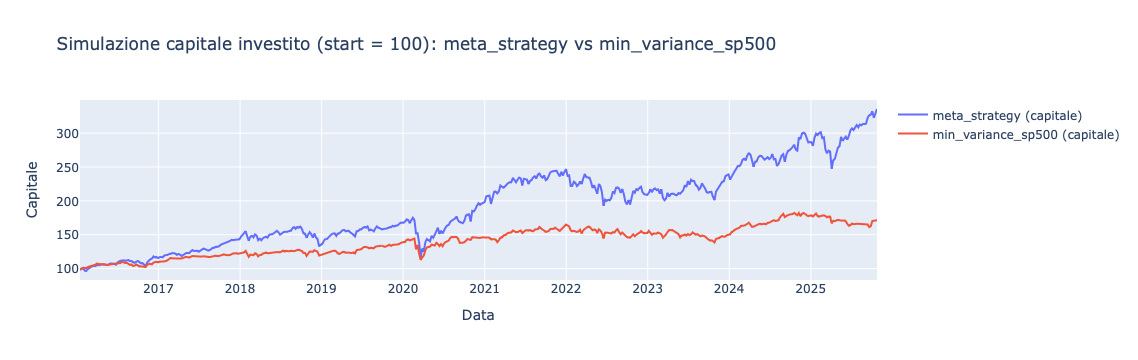

,meta_strategy,min_variance_sp500
2016-01-15,98.017038,99.034570
2016-01-22,99.727114,100.040497
2016-01-29,101.024182,101.204716
2016-02-05,96.922879,100.926484
2016-02-12,96.471505,100.733641
...,...,...
2025-09-26,327.039735,162.489725
2025-10-03,332.135827,170.323720
2025-10-10,322.679124,170.744225
2025-10-17,328.457072,171.204348


In [63]:
simulate_capital(
    "meta_strategy",
    "min_variance_sp500",
    start_capital=100,
    df=final_df
)